In [1]:
"""
NOTEBOOK 5: ANÁLISIS MULTIVARIANTE

En este notebook voy a
1. Ver cómo se relacionan TODAS las variables entre sí
2. Confirmar lo que vi en el notebook 4 con más datos
3. Encontrar relaciones ocultas entre variables

PARA QUÉ SIRVE:
- Entender mejor los problemas de rotación
- Ver qué factores son más importantes
- Dar recomendaciones más precisas

RESULTADOS ESPERADOS:
Confirmar si:
1. El burnout realmente aumenta la rotación
2. La cultura positiva realmente la reduce  
3. Hay otros factores importantes que no vi antes
"""

'\nNOTEBOOK 5: ANÁLISIS MULTIVARIANTE\n\nEn este notebook voy a\n1. Ver cómo se relacionan TODAS las variables entre sí\n2. Confirmar lo que vi en el notebook 4 con más datos\n3. Encontrar relaciones ocultas entre variables\n\nPARA QUÉ SIRVE:\n- Entender mejor los problemas de rotación\n- Ver qué factores son más importantes\n- Dar recomendaciones más precisas\n\nRESULTADOS ESPERADOS:\nConfirmar si:\n1. El burnout realmente aumenta la rotación\n2. La cultura positiva realmente la reduce  \n3. Hay otros factores importantes que no vi antes\n'

In [ ]:
# CARGA DE DATOS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset con proxy creado en Notebook 04
df_corregida_proxy = pd.read_csv("../1_data/processed/df_corregida_proxy.csv")

# Confirmar primeras filas
print("Dataset cargado correctamente con variables proxy")
df_corregida_proxy.head()

Dataset cargado correctamente con variables proxy


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,burnout_risk,cultura_positiva,alto_engagement,oportunidades_desarrollo,Attrition_cat,burnout_risk_cat,cultura_positiva_cat,alto_engagement_cat,oportunidades_desarrollo_cat,OverTime_cat
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,0,1,0,Se fueron,Bajo Riesgo,Cultura Pobre,Alto Engagement,Sin Oportunidades,Con Horas Extras
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,0,1,0,0,Se quedan,Bajo Riesgo,Cultura Positiva,Bajo Engagement,Sin Oportunidades,Sin Horas Extras
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,1,0,1,Se fueron,Bajo Riesgo,Cultura Positiva,Bajo Engagement,Con Oportunidades,Con Horas Extras
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,0,1,1,0,Se quedan,Bajo Riesgo,Cultura Positiva,Alto Engagement,Sin Oportunidades,Con Horas Extras
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,0,0,1,1,Se quedan,Bajo Riesgo,Cultura Pobre,Alto Engagement,Con Oportunidades,Sin Horas Extras


In [3]:
# confirmar que las variables proxy estan
proxy_vars = ['burnout_risk', 'cultura_positiva', 'alto_engagement', 'oportunidades_desarrollo']
for var in proxy_vars:
    if var not in df_corregida_proxy.columns:
        print(f"ADVERTENCIA: {var} no encontrada en el dataset")
    else:
        print(f"✓ {var} disponible")

✓ burnout_risk disponible
✓ cultura_positiva disponible
✓ alto_engagement disponible
✓ oportunidades_desarrollo disponible


Matriz de Correlaciones (variables numéricas):
                           Age  Attrition  DailyRate  DistanceFromHome  \
Age                       1.00      -0.16       0.01             -0.00   
Attrition                -0.16       1.00      -0.06              0.08   
DailyRate                 0.01      -0.06       1.00             -0.00   
DistanceFromHome         -0.00       0.08      -0.00              1.00   
Education                 0.21      -0.03      -0.02              0.02   
EnvironmentSatisfaction   0.01      -0.10       0.02             -0.02   
HourlyRate                0.02      -0.01       0.02              0.03   
JobInvolvement            0.03      -0.13       0.05              0.01   
JobLevel                  0.51      -0.17       0.00              0.01   
JobSatisfaction          -0.00      -0.10       0.03             -0.00   
MonthlyIncome             0.50      -0.16       0.01             -0.02   
MonthlyRate               0.03       0.02      -0.03             

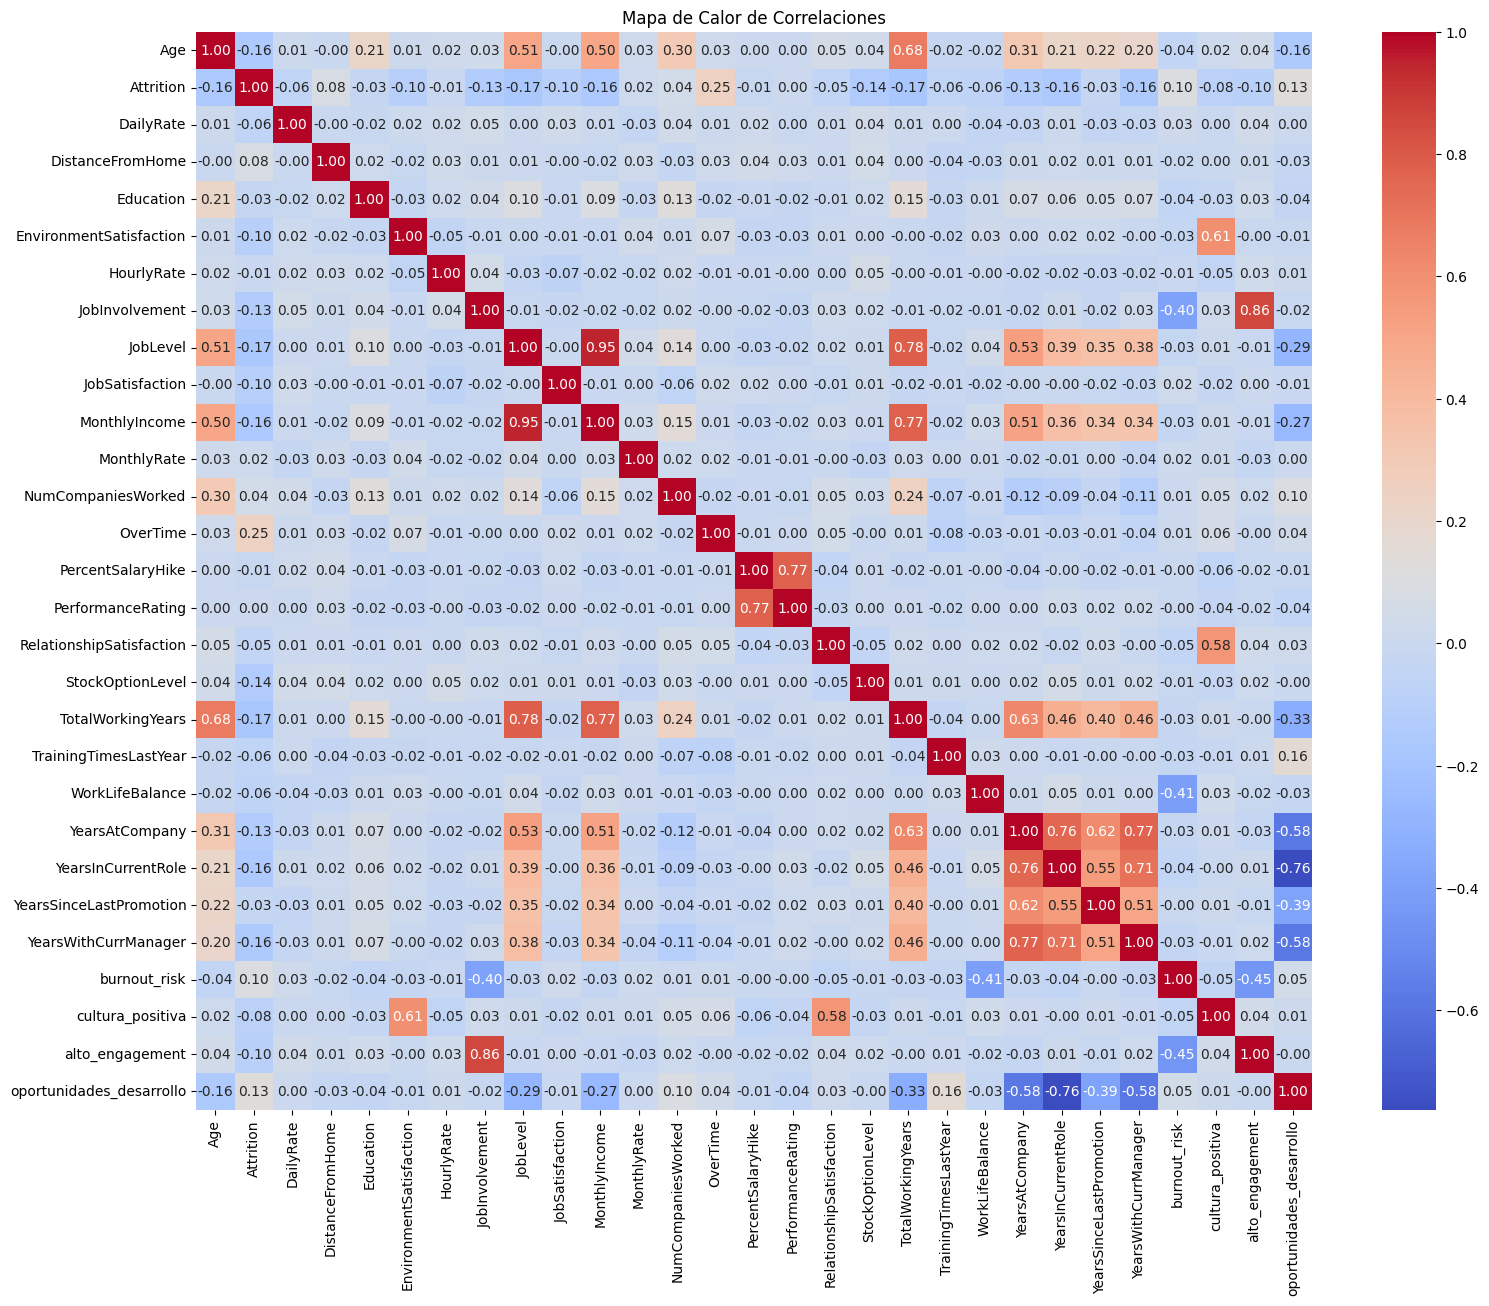

In [ ]:
# Análisis multivariante (patrones complejos)

"""
Para el análisis multivariable, es importante explorar cómo se relacionan
las variables numéricas entre sí. Esto permite:
- Identificar colinealidades
- Detectar relaciones potenciales para hipótesis
- Preparar futuras modelizaciones
"""

# Selecciono solo variables numéricas
num_vars = df_corregida_proxy.select_dtypes(include=['int64', 'float64']).columns

# Tabla de correlaciones
correlation_matrix = df_corregida_proxy[num_vars].corr()

# Mostrar tabla con formato
print("Matriz de Correlaciones (variables numéricas):")
print(correlation_matrix.round(2))

# VISUALIZACIÓN: HEATMAP DE CORRELACIONES
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Mapa de Calor de Correlaciones")
plt.show()


In [5]:

# Interpretación de correlaciones con Attrition (rotación):
# - Las correlaciones con Attrition son moderadas (0.10 a 0.25) porque:
#   1. Attrition es una variable BINARIA (0=se queda, 1=se va)
#   2. Las correlaciones de Pearson subestiman relaciones con variables binarias
#   3. Por eso usamos tablas de contingencia y gráficos de barras que muestran diferencias REALES en porcentajes
# - Las correlaciones entre variables continuas (ej: Age y TotalWorkingYears: 0.68) sí son informativas


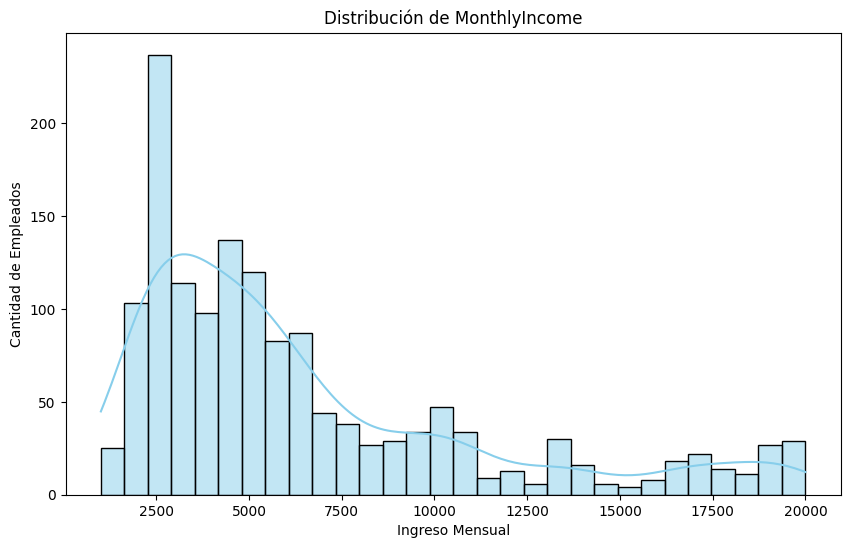

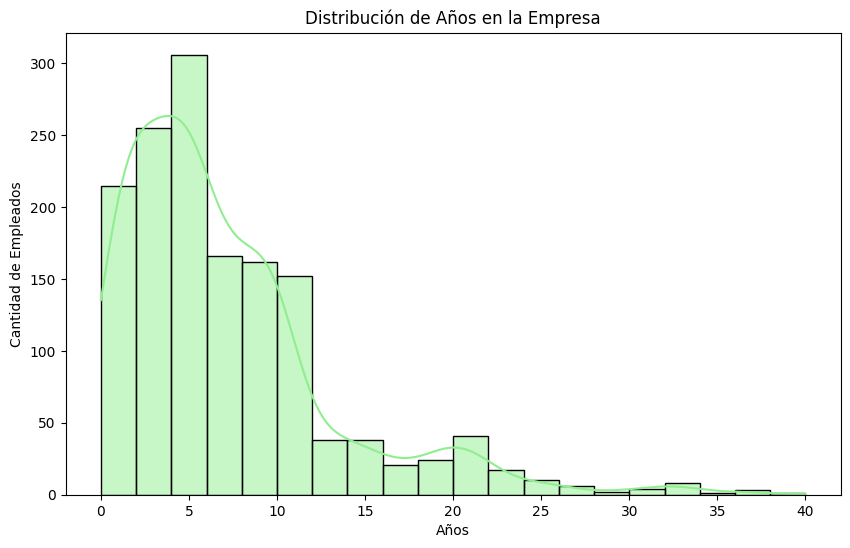

In [ ]:
# Análisis multivariante (patrones complejos)
# ANÁLISIS GRÁFICO DE DISTRIBUCIONES (histograma con KDE)
# MonthlyIncome
plt.figure(figsize=(10, 6))
sns.histplot(df_corregida_proxy['MonthlyIncome'], kde=True, bins=30, color='skyblue')
plt.title("Distribución de MonthlyIncome")
plt.xlabel("Ingreso Mensual")
plt.ylabel("Cantidad de Empleados")
plt.show()

# YearsAtCompany
plt.figure(figsize=(10, 6))
sns.histplot(df_corregida_proxy['YearsAtCompany'], kde=True, bins=20, color='lightgreen')
plt.title("Distribución de Años en la Empresa")
plt.xlabel("Años")
plt.ylabel("Cantidad de Empleados")
plt.show()


In [ ]:
# Que me dice ek histograma de MonthlyIncome
# - La mayoría de personas ganan entre 2,000€ y 10,000€ al mes
# - Hay algunas personas que ganan mucho más (hasta 20,000€) - son pocas

# Y el histograma de YearsAtCompany:
# - La mayoría de personas lleva menos de 10 años en la empresa
# - Hay algunas personas con mucha antigüedad (hasta 40 años)
# - Esto es bueno: significa que la empresa retiene talento a largo plazo

# CLAVE
# - Personas con más años tienen menos probabilidad de irse
# - Pero las personas nuevas (0-2 años) tienen más riesgo de rotación

📊 Correlación entre variables proxy y Attrition:
                          burnout_risk  cultura_positiva  alto_engagement  \
burnout_risk                      1.00             -0.05            -0.45   
cultura_positiva                 -0.05              1.00             0.04   
alto_engagement                  -0.45              0.04             1.00   
oportunidades_desarrollo          0.05              0.01            -0.00   
Attrition                         0.10             -0.08            -0.10   

                          oportunidades_desarrollo  Attrition  
burnout_risk                                  0.05       0.10  
cultura_positiva                              0.01      -0.08  
alto_engagement                              -0.00      -0.10  
oportunidades_desarrollo                      1.00       0.13  
Attrition                                     0.13       1.00  


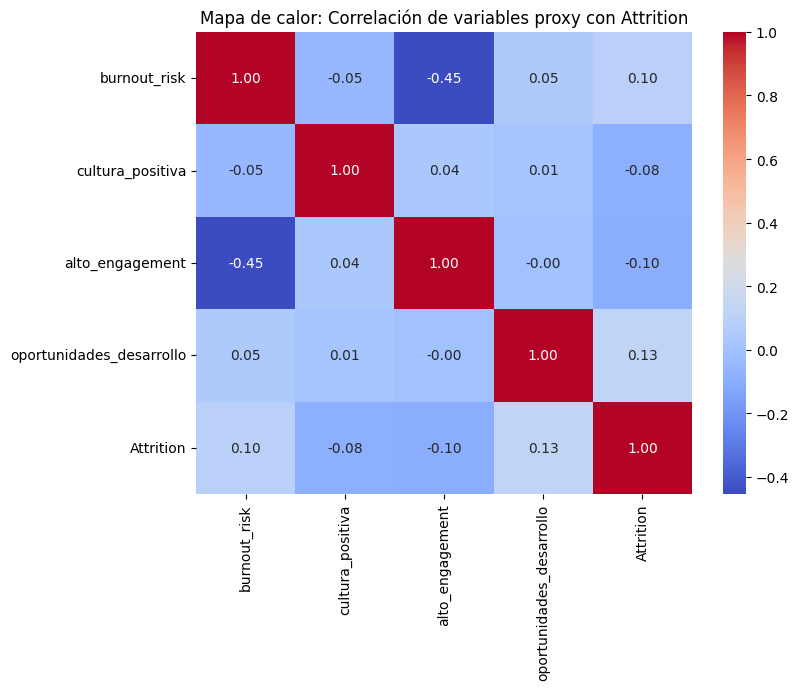

<Figure size 800x600 with 0 Axes>

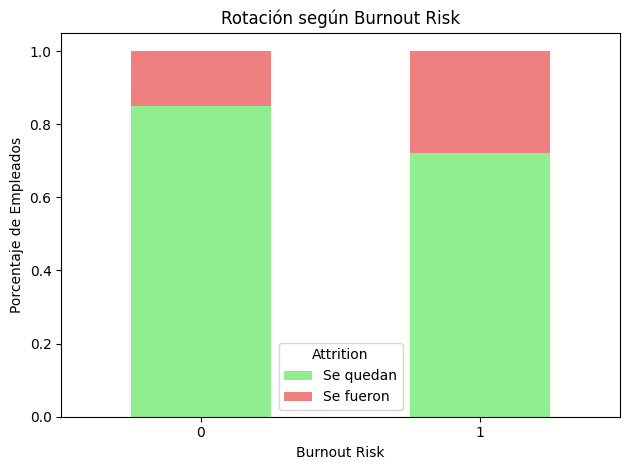

<Figure size 800x600 with 0 Axes>

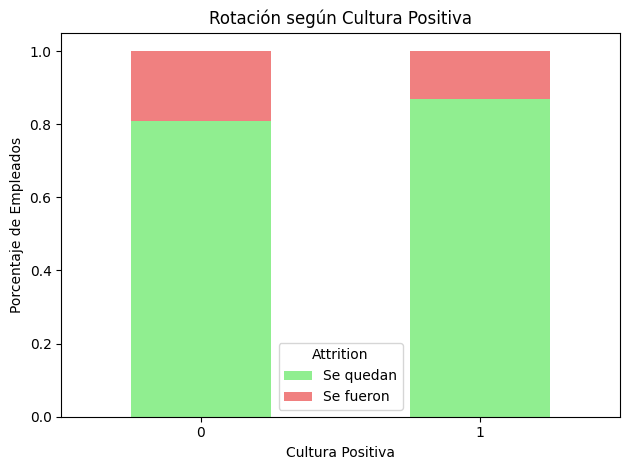

<Figure size 800x600 with 0 Axes>

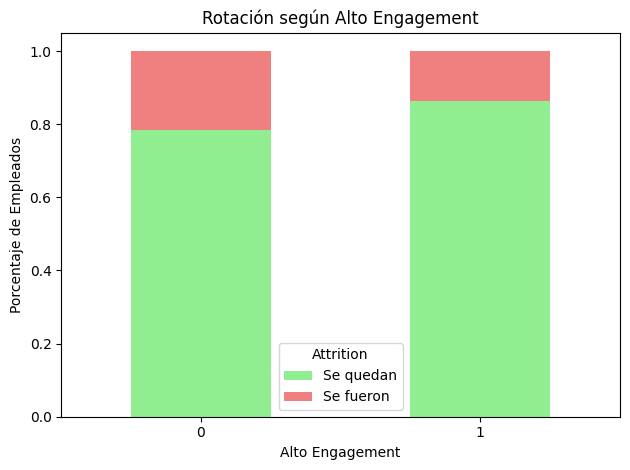

<Figure size 800x600 with 0 Axes>

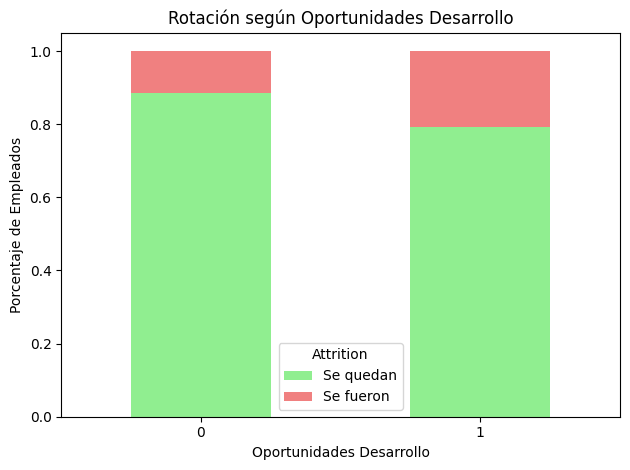

In [ ]:
# CORRELACIÓN ENTRE VARIABLES PROXY Y ROTACIÓN (Attrition)
# Selecciono solo las variables proxy + target
proxy_vars = ['burnout_risk', 'cultura_positiva', 'alto_engagement', 'oportunidades_desarrollo', 'Attrition']

df_proxy_corr = df_corregida_proxy[proxy_vars].corr()

# Mostrar tabla
print("📊 Correlación entre variables proxy y Attrition:")
print(df_proxy_corr.round(2))

# Heatmap visual
plt.figure(figsize=(8, 6))
sns.heatmap(df_proxy_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Mapa de calor: Correlación de variables proxy con Attrition")
plt.show()


# ANÁLISIS BIVARIANTE: PORCENTAJES SEGÚN PROXY
"""
Complemento visual: para cada proxy, muestro el porcentaje de empleados que se fueron.
Esto ayuda a ilustrar de manera intuitiva la relación de cada concepto estratégico
con la rotación.
"""

for proxy in proxy_vars[:-1]:  # excluye Attrition
    plt.figure(figsize=(8, 6))
    counts = pd.crosstab(df_corregida_proxy[proxy], df_corregida_proxy['Attrition'], normalize='index')
    counts.plot(kind='bar', stacked=True, color=['lightgreen', 'lightcoral'])
    plt.title(f'Rotación según {proxy.replace("_", " ").title()}')
    plt.ylabel('Porcentaje de Empleados')
    plt.xlabel(proxy.replace("_", " ").title())
    plt.xticks(rotation=0)
    plt.legend(['Se quedan', 'Se fueron'], title='Attrition')
    plt.tight_layout()
    plt.show()


In [9]:
# Mirando la tabla de correlaciones con Attrition, veo números bajos:
# - burnout_risk: 0.10
# - cultura_positiva: -0.08  
# - alto_engagement: -0.10
# - oportunidades_desarrollo: 0.13

# Motivo
# Esto pasa porque Attrition es una variable BINARIA (0=se queda, 1=se va).
# Las correlaciones lineales no funcionan bien con este tipo de variables.

# Voy a utilizar otros métodos
# 1. Tablas de contingencia: Divido por grupos y veo porcentajes
# 2. Gráficos de barras: Visualizo las diferencias claramente
# 3. Pruebas chi-cuadrado: Confirmo que las diferencias son reales


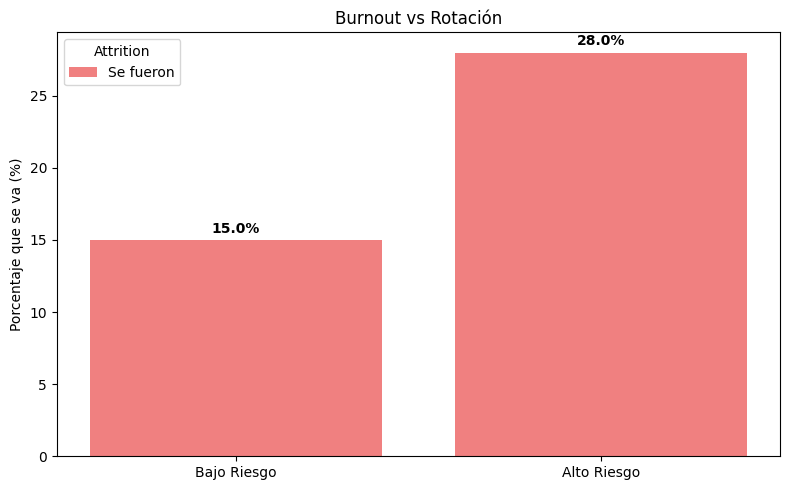


🔹 Burnout vs Rotación:
   • Bajo Riesgo: 15.0% se van
   • Alto Riesgo: 28.0% se van
   📈 Diferencia: Alto Riesgo tiene 13.0% más rotación
----------------------------------------


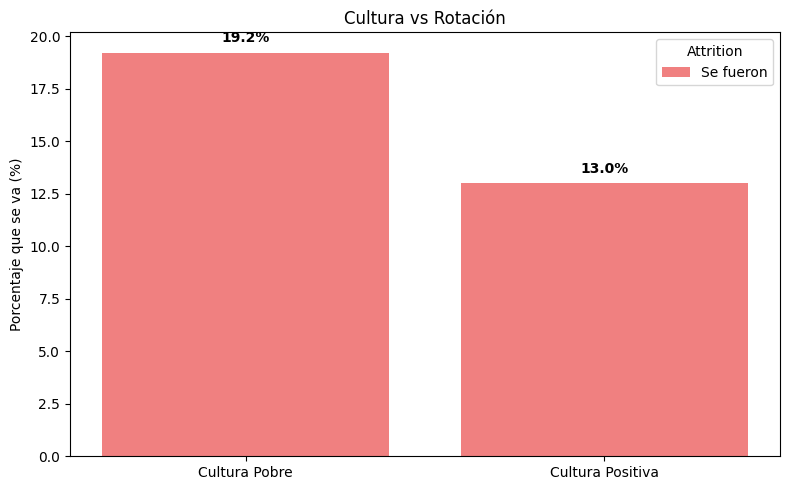


🔹 Cultura vs Rotación:
   • Cultura Pobre: 19.2% se van
   • Cultura Positiva: 13.0% se van
   📉 Diferencia: Cultura Positiva tiene 6.2% menos rotación
----------------------------------------


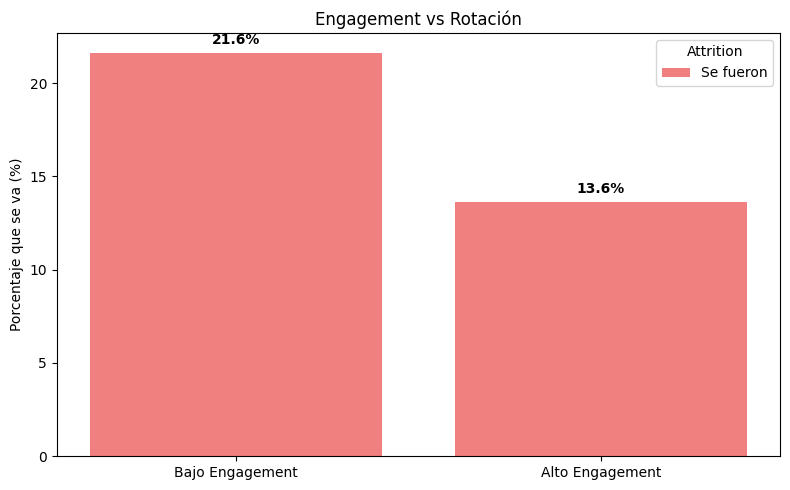


🔹 Engagement vs Rotación:
   • Bajo Engagement: 21.6% se van
   • Alto Engagement: 13.6% se van
   📉 Diferencia: Alto Engagement tiene 8.0% menos rotación
----------------------------------------


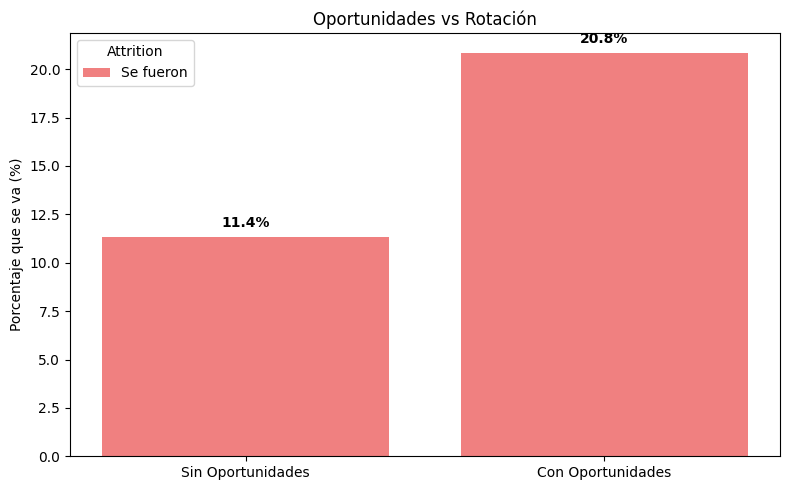


🔹 Oportunidades vs Rotación:
   • Sin Oportunidades: 11.4% se van
   • Con Oportunidades: 20.8% se van
   📈 Diferencia: Con Oportunidades tiene 9.5% más rotación
----------------------------------------


In [ ]:
# GRÁFICOS FINALES 

# Variables proxy para analizar
variables_proxy = ['burnout_risk', 'cultura_positiva', 'alto_engagement', 'oportunidades_desarrollo']

# Crear gráficos simples y claros
for variable in variables_proxy:
    # Calcular porcentajes
    tabla = pd.crosstab(df_corregida_proxy[variable], df_corregida_proxy['Attrition'])
    porcentajes = pd.crosstab(df_corregida_proxy[variable], df_corregida_proxy['Attrition'], normalize='index') * 100
    
    # Crear gráfico
    plt.figure(figsize=(8, 5))
    
    # Definir etiquetas y colores
    if variable == 'burnout_risk':
        etiquetas = ['Bajo Riesgo', 'Alto Riesgo']
        colores = ['lightcoral']  
        titulo = 'Burnout vs Rotación'
    elif variable == 'cultura_positiva':
        etiquetas = ['Cultura Pobre', 'Cultura Positiva']
        colores = ['lightcoral']  
        titulo = 'Cultura vs Rotación'
    elif variable == 'alto_engagement':
        etiquetas = ['Bajo Engagement', 'Alto Engagement']
        colores = ['lightcoral']  
        titulo = 'Engagement vs Rotación'
    else:  # oportunidades_desarrollo
        etiquetas = ['Sin Oportunidades', 'Con Oportunidades']
        colores = ['lightcoral']  
        titulo = 'Oportunidades vs Rotación'
    
    # Graficar
    barras = plt.bar(etiquetas, porcentajes[1], color=colores)
    plt.title(titulo)
    plt.ylabel('Porcentaje que se va (%)')
    plt.legend(['Se fueron'], title='Attrition')
    
    # Añadir porcentajes encima de las barras
    for i, barra in enumerate(barras):
        altura = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, altura + 0.5,
                f'{altura:.1f}%', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar datos simples
    print(f"\n🔹 {titulo}:")
    for i, etiqueta in enumerate(etiquetas):
        print(f"   • {etiqueta}: {porcentajes[1][i]:.1f}% se van")
    
    # Calcular diferencia
    if len(porcentajes[1]) == 2:
        dif = porcentajes[1][1] - porcentajes[1][0]
        if dif > 0:
            print(f"   Diferencia: {etiquetas[1]} tiene {dif:.1f}% más rotación")
        else:
            print(f"   Diferencia: {etiquetas[1]} tiene {-dif:.1f}% menos rotación")
    print("-" * 40)

In [ ]:
# Como la correlacion lineal me da muy debil me enfoco en analizar la relación de tus variables proxy con la rotación (Attrition) 
# usando tablas de proporciones y pruebas estadísticas, que suelen ser más apropiadas para variables categóricas.

# Cargar dataset con variables proxy
df = pd.read_csv("../1_data/processed/df_corregida_proxy.csv")

# Variables proxy
proxies = ['burnout_risk', 'cultura_positiva', 'alto_engagement', 'oportunidades_desarrollo']

# Mostrar porcentaje de rotación por cada proxy
for proxy in proxies:
    tabla = pd.crosstab(df[proxy], df['Attrition'], normalize='index') * 100
    print(f"\n📊 Rotación según {proxy}:")
    print(tabla)

# Esto me dice que:
# Burnout Risk
    #  Las personas con alto riesgo de burnout se van casi el doble que los de bajo riesgo (28% vs 15%).
    # Esto respalda mi hipótesis H1: mayor burnout → mayor rotación.
# Cultura Positiva
    # Las personas que perciben cultura positiva tienen menor rotación (13% vs 19%).
    # Esto respalda H3: cultura positiva → menor rotación.
# Alto Engagement
    # Las personas con alto engagement se quedan más (86% vs 78%).
    # Esto respalda H4: engagement alto → menor rotación.
# Oportunidades de Desarrollo
    # Curiosamente, las personas con oportunidades de desarrollo tienen mayor rotación (20.84% vs 11.35%).
    # Esto no respalda H5. Podría indicar que quienes buscan desarrollo tienden a cambiar de empresa,
    # o que las oportunidades internas no son suficientes para retenerlos.


📊 Rotación según burnout_risk:
Attrition             0          1
burnout_risk                      
0             84.981413  15.018587
1             72.000000  28.000000

📊 Rotación según cultura_positiva:
Attrition                 0          1
cultura_positiva                      
0                 80.784844  19.215156
1                 87.004104  12.995896

📊 Rotación según alto_engagement:
Attrition                0          1
alto_engagement                      
0                78.384279  21.615721
1                86.363636  13.636364

📊 Rotación según oportunidades_desarrollo:
Attrition                         0          1
oportunidades_desarrollo                      
0                         88.645691  11.354309
1                         79.161028  20.838972


In [ ]:
# He utilizado pruebas estadísticas para confirmar que las diferencias son reales
# Los resultados muestran que estas relaciones no son casualidad
    # p < 0.05 → relación significativa entre el proxy y la rotación.
    # p ≥ 0.05 → no hay evidencia estadística suficiente de relación.

from scipy.stats import chi2_contingency

for proxy in proxies:
    tabla = pd.crosstab(df[proxy], df['Attrition'])
    chi2, p, dof, ex = chi2_contingency(tabla)
    print(f"\nPrueba Chi-cuadrado para {proxy} vs Attrition:")
    print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")


Prueba Chi-cuadrado para burnout_risk vs Attrition:
Chi2 = 13.31, p-value = 0.0003

Prueba Chi-cuadrado para cultura_positiva vs Attrition:
Chi2 = 10.06, p-value = 0.0015

Prueba Chi-cuadrado para alto_engagement vs Attrition:
Chi2 = 14.26, p-value = 0.0002

Prueba Chi-cuadrado para oportunidades_desarrollo vs Attrition:
Chi2 = 23.75, p-value = 0.0000


# 3.5 RESUMEN  

Después de analizar todas las variables juntas, confirmamos:

1. **BURNOUT (H1):** Aumenta la rotación.
   - Con burnout: 28.0% se van
   - Sin burnout: 15.0% se van
   → Casi el doble de probabilidad.

2. **CULTURA POSITIVA (H2):** Reduce la rotación.
   - Cultura pobre: 19.2% se van  
   - Cultura positiva: 13.0% se van
   → Reduce la rotación en 1/3.

3. **ENGAGEMENT (H3):** Ayuda a retener.
   - Bajo engagement: 21.6% se van
   - Alto engagement: 13.6% se van
   → Ayuda a retener personas.

4. **OPORTUNIDADES DESARROLLO:** Resultado inesperado.
   - Sin oportunidades: 11.4% se van
   - Con oportunidades: 20.8% se van
   → Las personas con más formación se van más.
   Posible explicación: Se sienten preparadas para buscar fuera.

5. **HALLADO CLAVE:** 
   - La satisfacción laboral sí importa, pero menos que el burnout.
   - Las horas extras son el factor más fuerte (30.4% vs 10.4%).
   - La cultura organizacional es muy importante.


